In [23]:
from IPython.core.debugger import prompt
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict

In [2]:
load_dotenv()

True

In [3]:
# Model
model = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

In [10]:
class LLMState(TypedDict):
    question: str
    answer: str

In [11]:
def llm_qa(statres: LLMState) -> LLMState:
    question = statres["question"]

    # from the prompt
    prompt = f'Answer the following question:\n{question}'

    # LLM
    answer = model.invoke(prompt).content

    # Update the state
    return LLMState(question=question, answer=answer)

In [12]:
# Create graph
graph = StateGraph(LLMState)

In [13]:
# Add node
graph.add_node('llm_qa', llm_qa)

In [14]:
# Add edge
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

In [17]:
# Compile the graph
workflow = graph.compile()

In [20]:
# Execute the graph
initial_state = {
    'question': 'What is way to travel from SriLanka to India?'
}

result = workflow.invoke(initial_state)
print(result['question'])
print(result['answer'][0]['text'])

What is way to travel from SriLanka to India?
Traveling from Sri Lanka to India is quite easy as they are neighboring countries. Since Sri Lanka is an island, there are two main ways to travel: by air (most common) and by sea (limited).

Here are the details for each method:

### 1. By Air (Most Common & Fastest)
Flying is the primary way to travel between the two countries. There are numerous daily flights connecting major cities.

*   **Main Departure Point:** Bandaranaike International Airport (CMB) in Colombo.
*   **Main Arrival Points in India:** Chennai (MAA), Mumbai (BOM), Delhi (DEL), Bangalore (BLR), Madurai (IXM), Trichy (TRZ), and Kochi (COK).
*   **Airlines:** SriLankan Airlines, Air India, IndiGo, Vistara, and SpiceJet.
*   **Duration:** 
    *   Colombo to Chennai: ~1 hour 15 minutes.
    *   Colombo to Delhi: ~3 hours 30 minutes.

### 2. By Sea (Ferry Service)
After many years of suspension, a ferry service was recently resumed, though its schedule can be seasonal and su

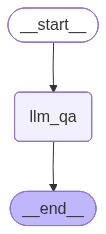

In [21]:
# Visualize the graph
from IPython.display import display, Image
Image(workflow.get_graph().draw_mermaid_png())